# Donwload Sentinel-3 LST and SYN Products

In this example, some Sentinel-3
[LST](https://sentiwiki.copernicus.eu/web/slstr-products#L2-LST-Products) and
[SYN](https://sentiwiki.copernicus.eu/web/synergy-products#L2-SYN-Products) products are
downloaded and their data plotted.


## Import Packages


In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from s3lst_ds.data_download.download_sentinel3 import download_products
from s3lst_ds.data_download.download_sentinel3_config import Sentinel3Config
from s3lst_ds.data_reading.s3_reader import Sen3Loader

## Download Products


### Configure

With the configuration below, one intends to:

- donwload NT (Non-Time Critical) Sentinel-3 Level-2LST and SYN products;
- to directory `./data`;
- for two date-ranges - from `2020-07-18` to `2020-07-19`, and from `2021-07-16` to
  `2021-07-26`;
- for the Lisbon metropolitan area (represented by a [WKT](https://wktmap.com/) string);
- solely products with a cloud cover fraction not larger than 30 % are to be considered;
- the products are to be processed, that is, georeferenced and subset to the bands and
  area of interest - using [`esa-snappy`](https://github.com/senbox-org/esa-snappy);
- the clouds are to be masked out;
- the whole procedure is to be logged into the terminal.


In [2]:
download_config = Sentinel3Config(
    out_dir=Path("./data"),
    timeliness="NT",
    start_sensing_dates=["2020-07-18", "2021-07-16"],
    end_sensing_dates=["2020-07-19", "2021-07-26"],
    geometry_aoi=(
        "POLYGON ((-9.53 38.57, -9.05 38.57, -9.05 38.92, -9.53 38.92, -9.53 38.57))"
    ),
    cloud_cover_max_aoi=30,
    process=True,
    process_engine="snappy",
    mask_clouds=True,
    log_mode="console",
)

### Download

To download the products through
[OData's API](https://documentation.dataspace.copernicus.eu/APIs/OData.html), the
function below is used.


In [3]:
download_products(download_config)


INFO     Downloading Sentinel-3 products for dates                                      
         - 2020-07-18 to 2020-07-19,                                                    
         - 2021-07-16 to 2021-07-26.                                                    

⠋        Querying Sentinel-3 LST products...0m
INFO     37 Sentinel-3 LST products have been found in the query:                       
         S3A_SL_2_LST____20200718T105333_20200718T105633_20200719T154051_0179_060_322_23
         40_LN2_O_NT_004.SEN3                                                           
         S3A_SL_2_LST____20200718T221028_20200718T221328_20200720T040806_0179_060_329_05
         40_LN2_O_NT_004.SEN3                                                           
         S3A_SL_2_LST____20200719T102722_20200719T103022_20200720T150613_0179_060_336_23
         40_LN2_O_NT_004.SEN3                                                           
         S3B_SL_2_LST____20200719T112855_20200719T113155_2020

## Read Products


In [4]:
# Get path to the first directory containing the LST and SYN products in the data folder
path_lst_syn = next(dir for dir in Path("./data").iterdir() if dir.is_dir())

# Read the LST and NDVI (from SYN) data
sen3_loader = Sen3Loader(path=path_lst_syn)
data_lst = next(iter(sen3_loader.get_var_by_name("LST").data_vars.values()))
data_ndvi = sen3_loader.get_var_by_name("NDVI")

# Extract the timestamp from the data
timestamp = sen3_loader.timestamp

## Plot LST and NDVI Data


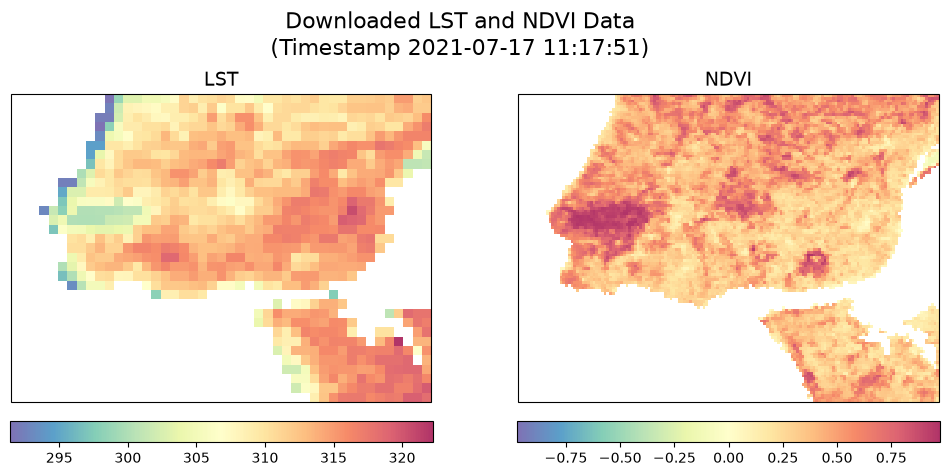

In [5]:
# Define the coordinate reference system to use in the plot
crs = ccrs.PlateCarree()


# Initialise figure and axes using a given CRS
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    subplot_kw={"projection": crs},
)
fig.suptitle(
    "Downloaded LST and NDVI Data"
    "\n"
    f"(Timestamp {timestamp.strftime('%Y-%m-%d %H:%M:%S')})",
    fontsize=16,
    y=1.05,
)

for ax, data, var in zip(axs, [data_lst, data_ndvi], ["LST", "NDVI"]):
    img = data.plot(
        ax=ax,
        cmap="Spectral_r",
        alpha=0.8,
        cbar_kwargs={
            "orientation": "horizontal",
            "pad": 0.05,
            "label": None,
        },
        # Project the data to the given CRS if it is not already in that CRS
        transform=crs,
    )  # type: ignore

    ax.set_title(var, fontsize=14)

plt.show()